In [1]:
!pip install transformers opendatasets --quiet
!pip install matplotlib seaborn --quiet

In [3]:
import json
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import opendatasets as od

In [4]:
# --- 2. Download Data ---
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eitharmoutasim
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 135MB/s]

In [5]:
# --- 3. Load and Explore Data ---
data_path = "news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json"

headlines = []
labels = []

with open(data_path, 'r') as f:
    for line in f:
        item = json.loads(line)
        headlines.append(item['headline'])
        labels.append(item['is_sarcastic'])

df = pd.DataFrame({'headline': headlines, 'is_sarcastic': labels})

print(f"Dataset size: {len(df)}")
print(f"\nClass distribution:")
print(df['is_sarcastic'].value_counts())
print(f"\nSample headlines:")
print(df.head(10))

Dataset size: 26709

Class distribution:
is_sarcastic
0    14985
1    11724
Name: count, dtype: int64

Sample headlines:
                                            headline  is_sarcastic
0  former versace store clerk sues over secret 'b...             0
1  the 'roseanne' revival catches up to our thorn...             0
2  mom starting to fear son's web series closest ...             1
3  boehner just wants wife to listen, not come up...             1
4  j.k. rowling wishes snape happy birthday in th...             0
5                        advancing the world's women             0
6     the fascinating case for eating lab-grown meat             0
7  this ceo will send your kids to school, if you...             0
8  top snake handler leaves sinking huckabee camp...             1
9  friday's morning email: inside trump's presser...             0


In [6]:
# --- 4. Train/Validation/Test Split ---
# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    df['headline'].values,
    df['is_sarcastic'].values,
    test_size=0.15,
    random_state=42,
    stratify=df['is_sarcastic'].values
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")



Train size: 18706
Validation size: 3996
Test size: 4007


In [16]:
# --- 5. Tokenizer Setup ---
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Check max length distribution to choose appropriate max_len
#lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in X_train[:1000]]
lengths = [len(tokenizer(text, add_special_tokens=True)['input_ids']) for text in X_train[:1000]]
print(f"\nToken length stats (sample of 1000):")
print(f"Mean: {np.mean(lengths):.1f}")
print(f"Median: {np.median(lengths):.1f}")
print(f"95th percentile: {np.percentile(lengths, 95):.1f}")
print(f"Max: {np.max(lengths)}")

MAX_LEN = 64  # Covers most headlines efficiently


Token length stats (sample of 1000):
Mean: 14.8
Median: 14.0
95th percentile: 22.0
Max: 32


In [19]:
# --- 6. Dataset Class ---
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


In [20]:
# Create datasets
train_dataset = SarcasmDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = SarcasmDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = SarcasmDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [21]:
#Model Architecture
class SarcasmClassifier(nn.Module):
    def __init__(self, model_name, n_classes=2, n_freeze_layers=3, dropout=0.3):
        super(SarcasmClassifier, self).__init__()

        # Load pretrained transformer backbone
        self.bert = AutoModel.from_pretrained(model_name)

        # Freeze embedding and first N transformer layers
        # DistilBERT has 6 layers total (0-5)
        # We freeze layers 0 to n_freeze_layers-1

        # Freeze embeddings
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False

        # Freeze first N transformer layers
        for i, layer in enumerate(self.bert.transformer.layer):
            if i < n_freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False

        # Classification head
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        # Get transformer outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
                # Use [CLS] token representation (first token)
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Apply dropout and classification
        dropout_output = self.dropout(pooled_output)
        logits = self.classifier(dropout_output)

        return logits


In [22]:
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

model = SarcasmClassifier(
    model_name=MODEL_NAME,
    n_classes=2,
    n_freeze_layers=3,
    dropout=0.3
).to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")



Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 66,364,418
Trainable parameters: 21,265,154
Trainable %: 32.04%


In [23]:
# --- 8. Training Setup ---
EPOCHS = 5
LEARNING_RATE = 2e-5

# Optimizer - only optimize trainable parameters
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=0.01
)

# Learning rate scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
# Loss function
criterion = nn.CrossEntropyLoss()

In [24]:
# --- 9. Training Functions ---
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

In [25]:
def eval_epoch(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

In [26]:
# --- 10. Training Loop ---
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0
best_model_state = None

print("\n" + "="*50)
print("Starting Training")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc * 100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"✓ New best model saved (Val Acc: {best_val_acc * 100:.2f}%)")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


Starting Training

Epoch 1/5


Evaluating: 100%|██████████| 125/125 [00:08<00:00, 14.78it/s]


Train Loss: 0.3927 | Train Acc: 0.8043
Val Loss:   0.2391 | Val Acc:   0.9007
✓ New best model saved (Val Acc: 0.9007)

Epoch 2/5


Evaluating: 100%|██████████| 125/125 [00:07<00:00, 15.70it/s]


Train Loss: 0.2176 | Train Acc: 0.9120
Val Loss:   0.2129 | Val Acc:   0.9152
✓ New best model saved (Val Acc: 0.9152)

Epoch 3/5


...

Train Loss: 0.1596 | Train Acc: 0.9379
Val Loss:   0.2550 | Val Acc:   0.9082

Epoch 4/5


Evaluating: 100%|██████████| 125/125 [00:07<00:00, 15.66it/s]


Train Loss: 0.1222 | Train Acc: 0.9542
Val Loss:   0.2222 | Val Acc:   0.9232
✓ New best model saved (Val Acc: 0.9232)

Epoch 5/5


Evaluating: 100%|██████████| 125/125 [00:07<00:00, 15.87it/s]

Train Loss: 0.0985 | Train Acc: 0.9637
Val Loss:   0.2271 | Val Acc:   0.9239
✓ New best model saved (Val Acc: 0.9239)

Best Validation Accuracy: 0.9239


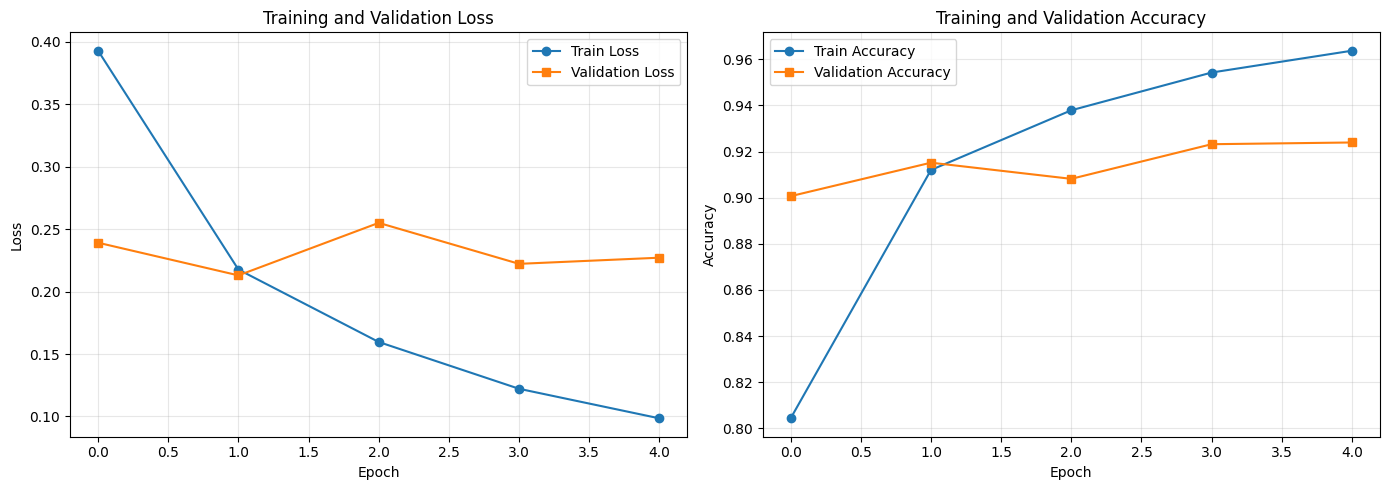


Training curves saved to 'training_curves.png'


In [27]:
# --- 11. Training Report - Loss and Accuracy Curves ---
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining curves saved to 'training_curves.png'")

In [29]:
# --- 12. Test Evaluation ---
# Load best model
model.load_state_dict(best_model_state)

test_loss, test_acc = eval_epoch(model, test_loader, criterion, device)

print("\n" + "="*50)
print("TEST RESULTS")
print("="*50)
print(f"Test Loss: {test_loss* 100:.2f}%")
print(f"TEST ACCURACY: {test_acc * 100:.2f}%")
# Detailed classification report
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Not Sarcastic', 'Sarcastic']))

Evaluating: 100%|██████████| 126/126 [00:07<00:00, 15.84it/s]



TEST RESULTS
Test Loss: 0.2326
TEST ACCURACY: 91.96%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.92      0.94      0.93      2248
    Sarcastic       0.92      0.90      0.91      1759

     accuracy                           0.92      4007
    macro avg       0.92      0.92      0.92      4007
 weighted avg       0.92      0.92      0.92      4007



In [30]:
# --- 17. Summary Report ---
print("\n" + "="*50)
print("EXERCISE 5 — SUMMARY REPORT")
print("="*50)

print("\n📋 MODEL ARCHITECTURE:")
print(f"   • Base Model: {MODEL_NAME}")
print(f"   • Frozen Layers: Embeddings + first 3 transformer blocks")
print(f"   • Trainable Layers: Last 3 transformer blocks + classification head")
print(f"   • Classification Head: Dropout(0.3) → Linear(768, 2)")
print(f"   • Total Parameters: {total_params:,}")
print(f"   • Trainable Parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

print("\n🎯 RATIONALE:")
print("   • DistilBERT chosen for efficiency (66M params vs 110M for BERT)")
print("   • 97% of BERT performance at 60% faster training")
print("   • Partial freezing prevents overfitting on smaller fine-tuning")
print("   • Dropout(0.3) adds regularization for better generalization")

print("\n📊 TRAINING RESULTS:")
print(f"   • Best Validation Accuracy: {best_val_acc:.4f}")
print(f"   • Test Accuracy: {test_acc:.4f}")
print(f"   • Training Epochs: {EPOCHS}")
print(f"   • Batch Size: {BATCH_SIZE}")
print(f"   • Learning Rate: {LEARNING_RATE}")

print("\n✅ DELIVERABLES:")
print("   ✓ Fine-tuned transformer model")
print("   ✓ Model architecture documentation")
print("   ✓ Training curves (loss and accuracy)")
print("   ✓ Test accuracy score")
print("   ✓ Live inference demo")

print("\n" + "="*50)


EXERCISE 5 — SUMMARY REPORT

📋 MODEL ARCHITECTURE:
   • Base Model: distilbert-base-uncased
   • Frozen Layers: Embeddings + first 3 transformer blocks
   • Trainable Layers: Last 3 transformer blocks + classification head
   • Classification Head: Dropout(0.3) → Linear(768, 2)
   • Total Parameters: 66,364,418
   • Trainable Parameters: 21,265,154 (32.04%)

🎯 RATIONALE:
   • DistilBERT chosen for efficiency (66M params vs 110M for BERT)
   • 97% of BERT performance at 60% faster training
   • Partial freezing prevents overfitting on smaller fine-tuning
   • Dropout(0.3) adds regularization for better generalization

📊 TRAINING RESULTS:
   • Best Validation Accuracy: 0.9239
   • Test Accuracy: 0.9196
   • Training Epochs: 5
   • Batch Size: 32
   • Learning Rate: 2e-05

✅ DELIVERABLES:
   ✓ Fine-tuned transformer model
   ✓ Model architecture documentation
   ✓ Training curves (loss and accuracy)
   ✓ Test accuracy score
   ✓ Live inference demo



In [34]:
# --- 15. Gradio Live Inference Demo ---
!pip install gradio --quiet
import gradio as gr
import torch

def detect_sarcasm(headline):
    if not headline or not headline.strip():
        return "⚠️ Please enter a valid headline."

    # Set model to evaluation mode
    model.eval()

    # Tokenize the input
    encoding = tokenizer(
        headline,
        add_special_tokens=True,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    ).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(encoding['input_ids'], encoding['attention_mask'])
        probs = torch.softmax(outputs, dim=1)[0]

    pred_idx = torch.argmax(outputs, dim=1).item()
    confidence = probs[pred_idx].item()

    # Format the output
    is_sarcastic = pred_idx == 1
    label = "😏 **SARCASTIC**" if is_sarcastic else "📰 **NOT SARCASTIC**"

    prob_sarcastic = probs[1].item() * 100
    prob_not = probs[0].item() * 100

    result_text = f"""
    ### 🎯 Prediction: {label}

    **Confidence:** {confidence * 100:.2f}%

    **Probability Breakdown:**
    - 📰 Not Sarcastic: `{prob_not:.2f}%`
    - 😏 Sarcastic: `{prob_sarcastic:.2f}%`
    """
    return result_text

# Create the Gradio Interface
demo = gr.Interface(
    fn=detect_sarcasm,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Enter a news headline here...",
        label="News Headline"
    ),
    outputs=gr.Markdown(),
    title="🎯 Sarcasm Detector",
    description="Enter a news headline below, and the fine-tuned DistilBERT model will predict whether it is sarcastic or factual.",
    examples=[
        ["Scientists discover water is wet"],
        ["Area man still believes he'll be famous someday"],
        ["Local dog elected mayor, immediately fixes potholes"],
        ["Company announces record profits, cuts employee benefits"],
        ["Breaking: gravity still works after all these years"]
    ],
    theme=gr.themes.Soft()
)

# Launch the app
print("Launching Gradio Demo...")
demo.launch()

Launching Gradio Demo...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0af5ea1dba6a3ee94b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
